In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

print("Data Center Dashboard Project Started!")

Data Center Dashboard Project Started!


In [2]:
# Generate simulated data center server data

np.random.seed(42)

servers = pd.DataFrame({
    "Server": [f"Server-{i+1}" for i in range(100)],
    "CPU_Usage": np.random.randint(10, 100, 100),
    "Memory_Usage": np.random.randint(20, 100, 100),
    "Temperature": np.random.randint(18, 45, 100),
    "Power_Usage": np.random.randint(200, 850, 100),
    "Network_Traffic": np.random.randint(100, 1000, 100)
})

servers.head()

,Server,CPU_Usage,Memory_Usage,Temperature,Power_Usage,Network_Traffic
0,Server-1,61,90,43,779,719
1,Server-2,24,28,23,597,104
2,Server-3,81,20,40,476,202
3,Server-4,70,27,21,703,295
4,Server-5,30,82,40,591,873


In [3]:
# Save the dataset

servers.to_csv("../data/server_data.csv", index=False)

print("Dataset saved successfully!")

OSError: Cannot save file into a non-existent directory: '..\data'

In [4]:
servers.to_csv("data/server_data.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


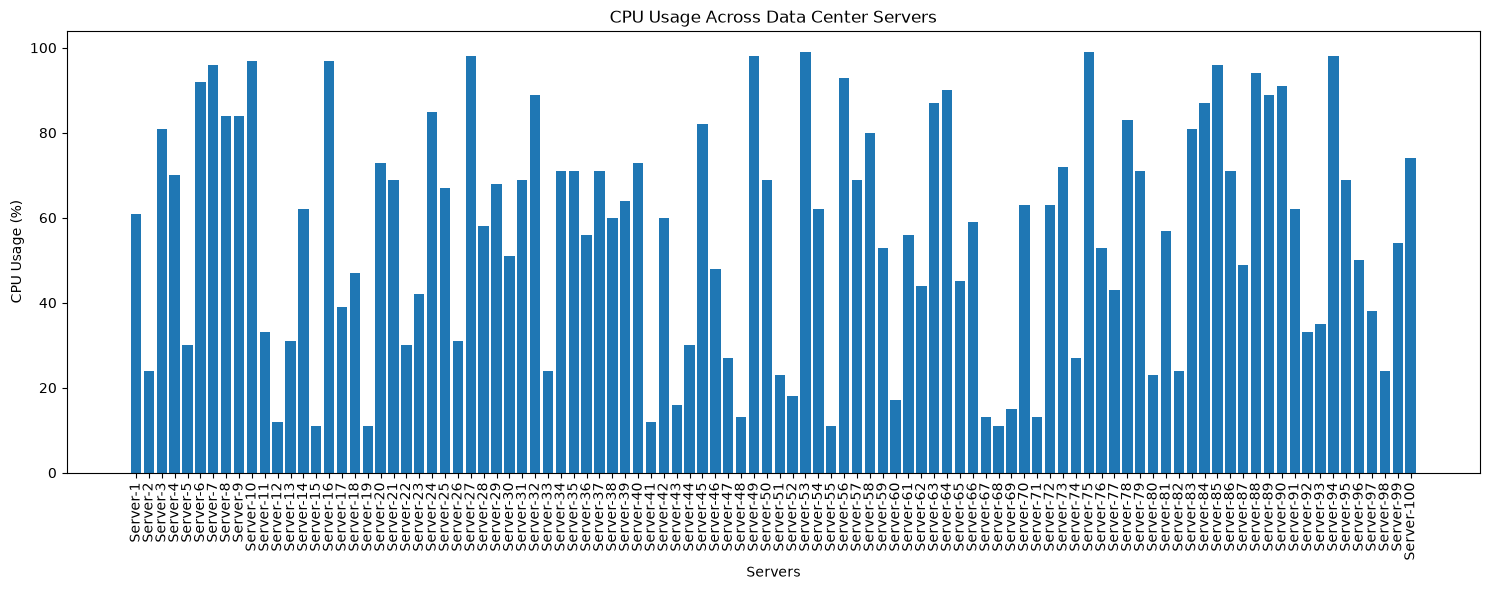

In [5]:
# CPU Usage by Server

plt.figure(figsize=(15,6))

plt.bar(servers["Server"], servers["CPU_Usage"])

plt.title("CPU Usage Across Data Center Servers")
plt.xlabel("Servers")
plt.ylabel("CPU Usage (%)")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'images/cpu_usage.png'

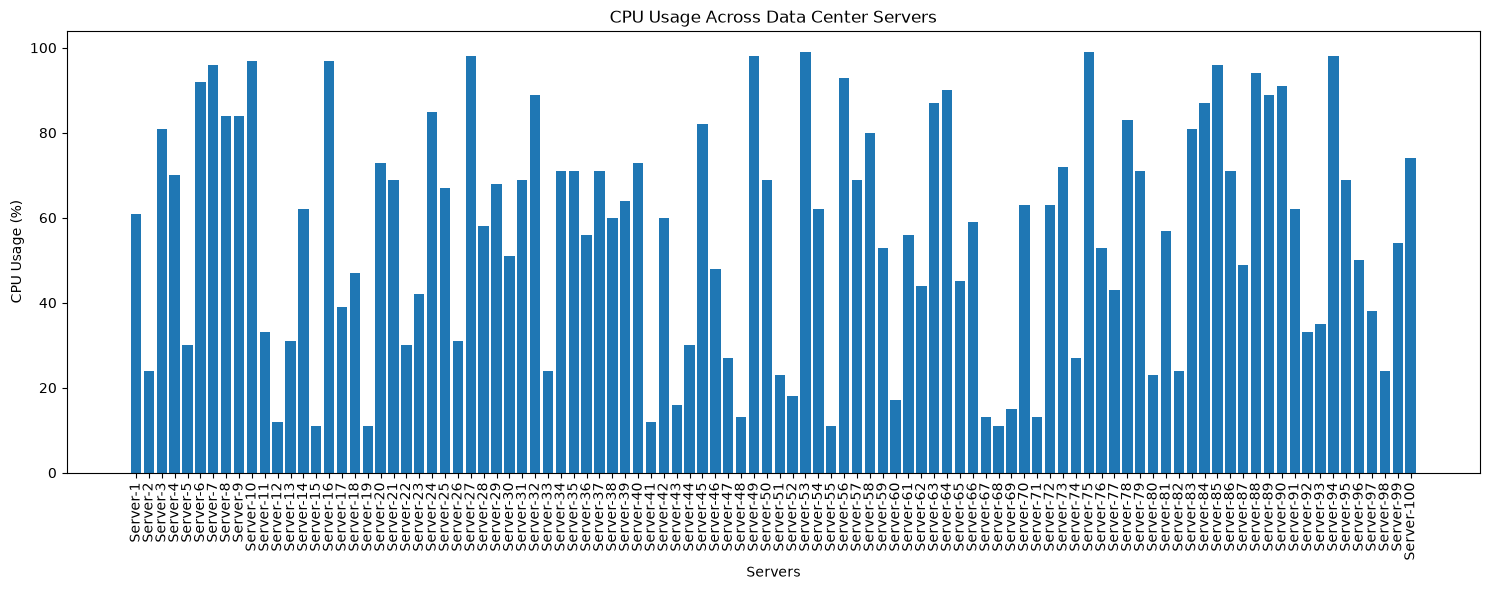

In [6]:
# Save CPU Usage chart

plt.figure(figsize=(15,6))

plt.bar(servers["Server"], servers["CPU_Usage"])

plt.title("CPU Usage Across Data Center Servers")
plt.xlabel("Servers")
plt.ylabel("CPU Usage (%)")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("images/cpu_usage.png")

plt.show()

print("Chart saved!")

In [7]:
import os

os.makedirs("images", exist_ok=True)
print(os.listdir())

['.git', 'dashboard.ipynb', 'data', 'images', 'notebook', 'README.md', 'requirements.txt']


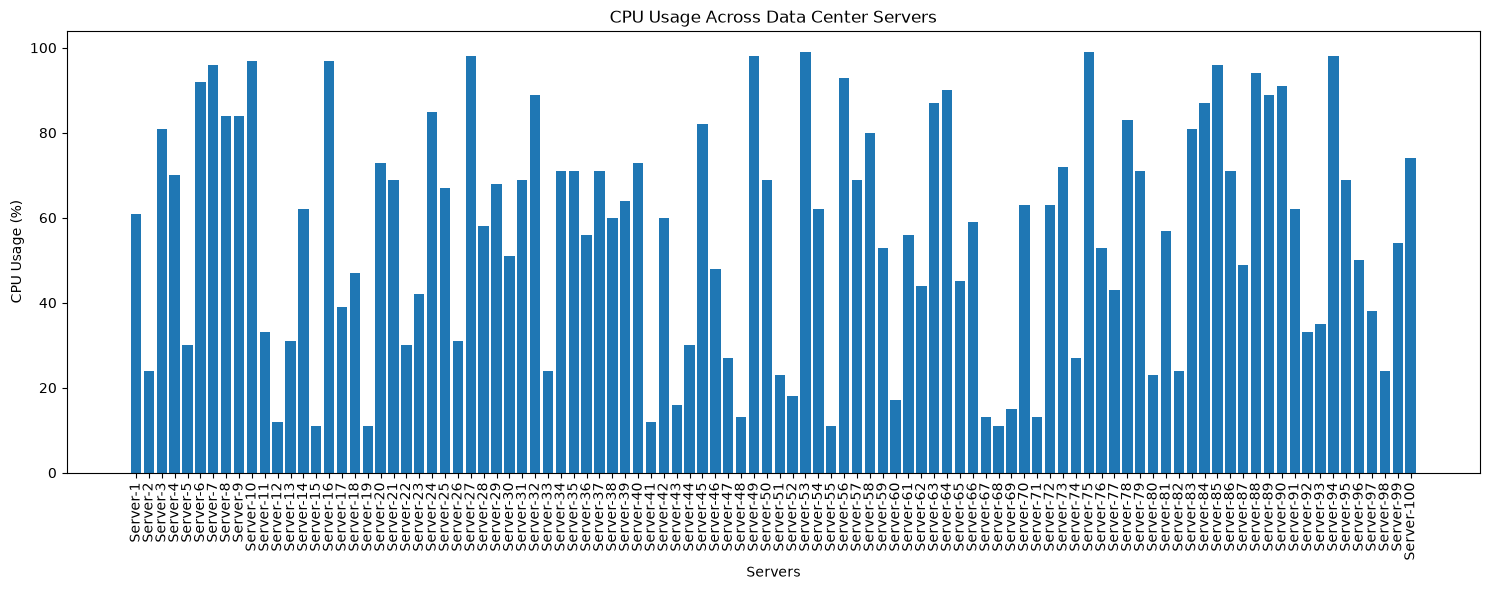

Chart saved!


In [8]:
# Save CPU Usage chart

plt.figure(figsize=(15,6))

plt.bar(servers["Server"], servers["CPU_Usage"])

plt.title("CPU Usage Across Data Center Servers")
plt.xlabel("Servers")
plt.ylabel("CPU Usage (%)")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("images/cpu_usage.png")

plt.show()

print("Chart saved!")

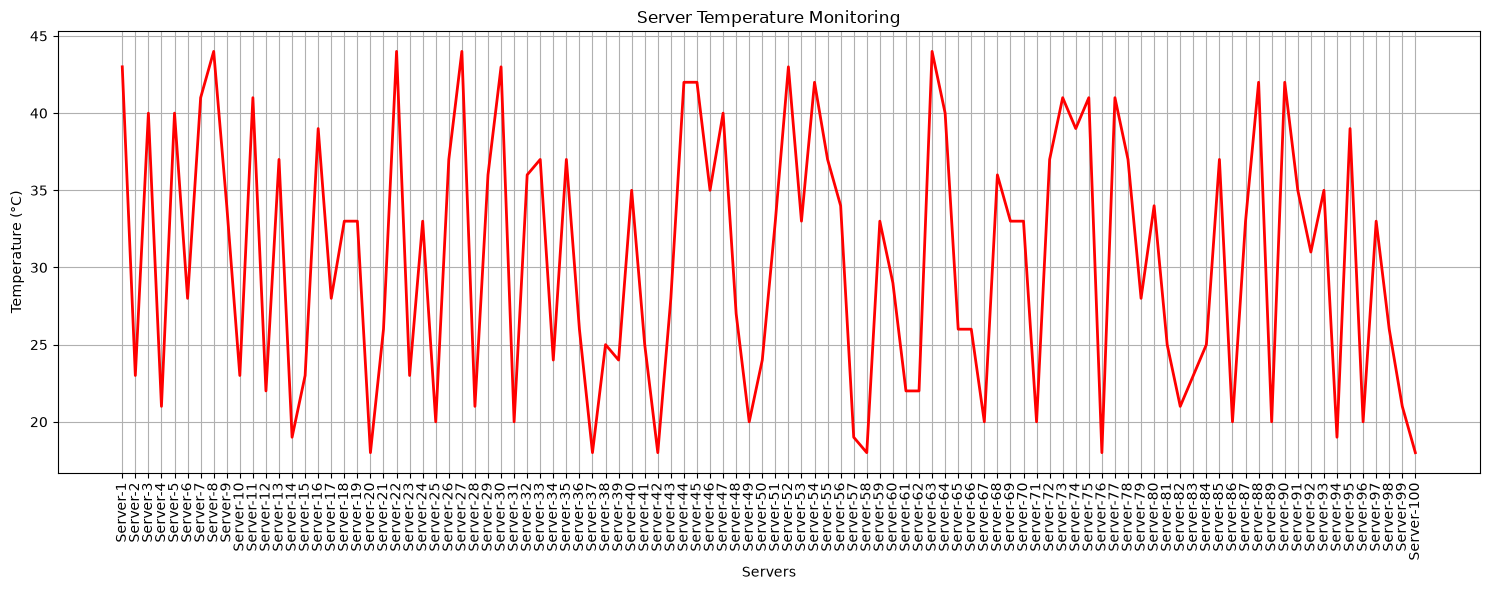

Temperature chart saved!


In [9]:
plt.figure(figsize=(15,6))

plt.plot(
    servers["Server"],
    servers["Temperature"],
    color="red",
    linewidth=2
)

plt.title("Server Temperature Monitoring")
plt.xlabel("Servers")
plt.ylabel("Temperature (°C)")

plt.xticks(rotation=90)

plt.grid(True)

plt.tight_layout()

plt.savefig("images/server_temperature.png")

plt.show()

print("Temperature chart saved!")

In [10]:
critical = servers[servers["Temperature"] > 35]

critical

,Server,CPU_Usage,Memory_Usage,Temperature,Power_Usage,Network_Traffic
0,Server-1,61,90,43,779,719
2,Server-3,81,20,40,476,202
4,Server-5,30,82,40,591,873
6,Server-7,96,27,41,394,983
7,Server-8,84,54,44,600,449
10,Server-11,33,24,41,659,922
12,Server-13,31,47,37,574,755
15,Server-16,97,91,39,429,735
21,Server-22,30,81,44,425,930
25,Server-26,31,84,37,680,445


In [11]:
print("Total Servers:", len(servers))
print("Critical Servers:", len(critical))
print("Average CPU Usage:", round(servers["CPU_Usage"].mean(), 2), "%")
print("Average Temperature:", round(servers["Temperature"].mean(), 2), "°C")
print("Average Power Usage:", round(servers["Power_Usage"].mean(), 2), "Watts")

Total Servers: 100
Critical Servers: 35
Average CPU Usage: 56.68 %
Average Temperature: 30.64 °C
Average Power Usage: 511.76 Watts


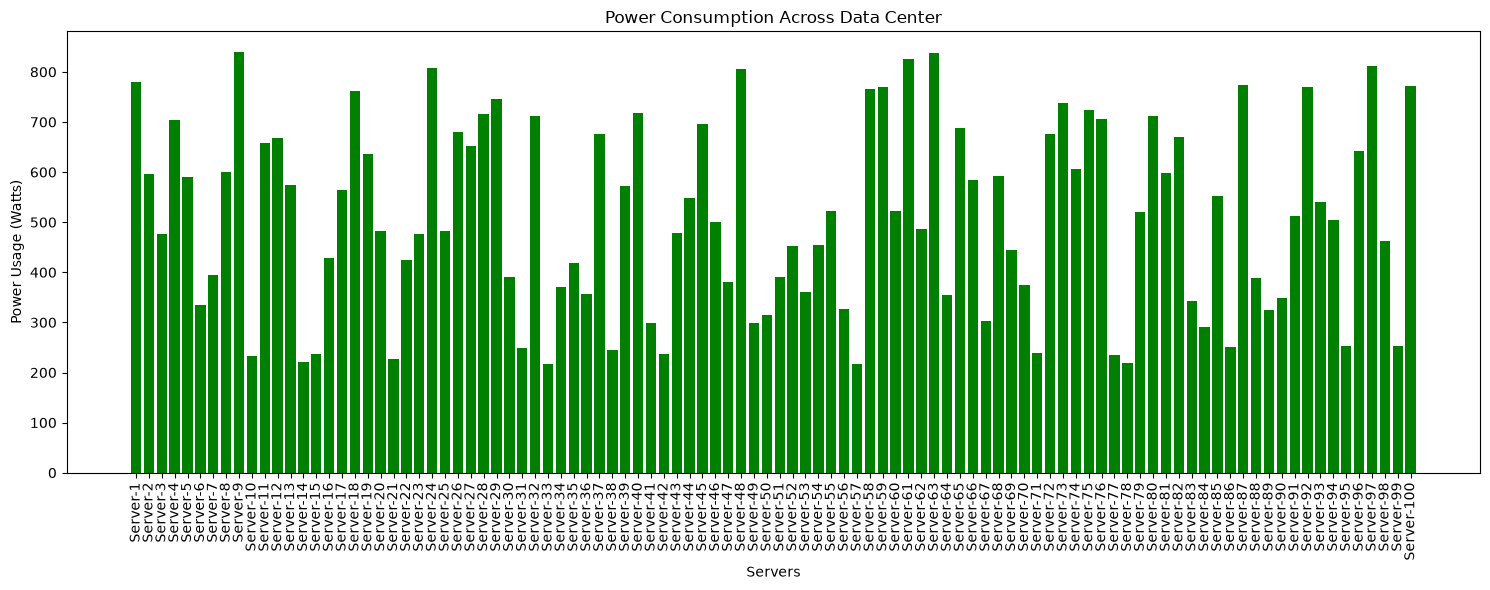

Power chart saved!


In [12]:
plt.figure(figsize=(15,6))

plt.bar(
    servers["Server"],
    servers["Power_Usage"],
    color="green"
)

plt.title("Power Consumption Across Data Center")
plt.xlabel("Servers")
plt.ylabel("Power Usage (Watts)")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("images/power_usage.png")

plt.show()

print("Power chart saved!")

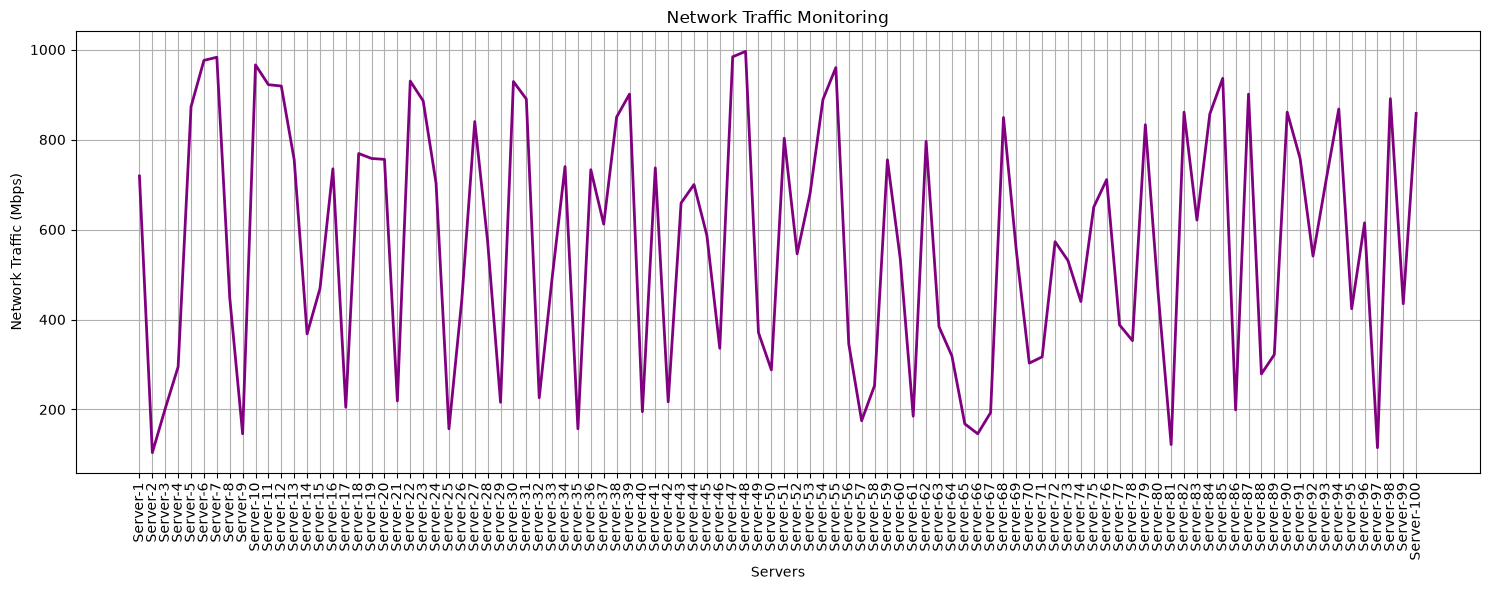

Network chart saved!


In [13]:
plt.figure(figsize=(15,6))

plt.plot(
    servers["Server"],
    servers["Network_Traffic"],
    color="purple",
    linewidth=2
)

plt.title("Network Traffic Monitoring")
plt.xlabel("Servers")
plt.ylabel("Network Traffic (Mbps)")

plt.xticks(rotation=90)

plt.grid(True)

plt.tight_layout()

plt.savefig("images/network_traffic.png")

plt.show()

print("Network chart saved!")

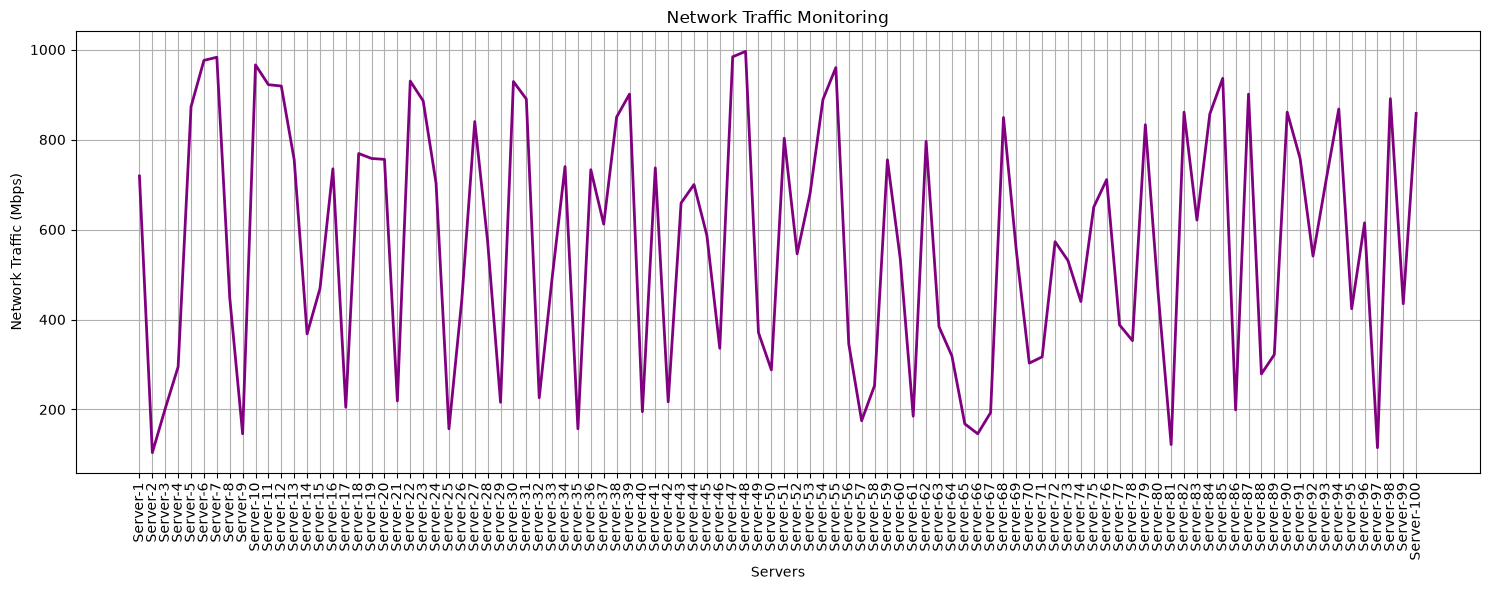

Network chart saved!


In [14]:
plt.figure(figsize=(15,6))

plt.plot(
    servers["Server"],
    servers["Network_Traffic"],
    color="purple",
    linewidth=2
)

plt.title("Network Traffic Monitoring")
plt.xlabel("Servers")
plt.ylabel("Network Traffic (Mbps)")

plt.xticks(rotation=90)

plt.grid(True)

plt.tight_layout()

plt.savefig("images/network_traffic.png")

plt.show()

print("Network chart saved!")

In [15]:
# Create Server Health Status

def server_status(row):
    if row["Temperature"] > 35 or row["CPU_Usage"] > 90:
        return "Critical"
    elif row["Temperature"] > 30 or row["CPU_Usage"] > 70:
        return "Warning"
    else:
        return "Healthy"

servers["Status"] = servers.apply(server_status, axis=1)

servers.head()

,Server,CPU_Usage,Memory_Usage,Temperature,Power_Usage,Network_Traffic,Status
0,Server-1,61,90,43,779,719,Critical
1,Server-2,24,28,23,597,104,Healthy
2,Server-3,81,20,40,476,202,Critical
3,Server-4,70,27,21,703,295,Healthy
4,Server-5,30,82,40,591,873,Critical


In [16]:
status_counts = servers["Status"].value_counts()

print(status_counts)

Status
Critical    41
Healthy     33
Warning     26
Name: count, dtype: int64


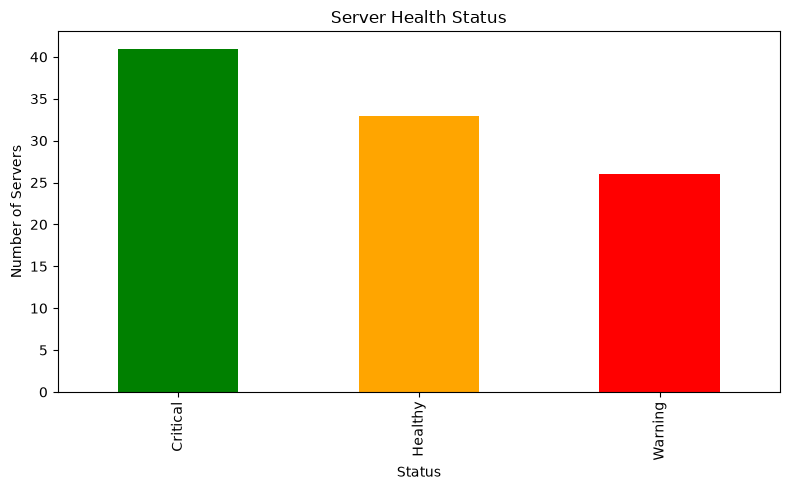

Server health chart saved!


In [17]:
plt.figure(figsize=(8,5))

status_counts.plot(
    kind="bar",
    color=["green", "orange", "red"]
)

plt.title("Server Health Status")
plt.xlabel("Status")
plt.ylabel("Number of Servers")

plt.tight_layout()

plt.savefig("images/server_health_status.png")

plt.show()

print("Server health chart saved!")

In [19]:
# Save updated dataset with server health status

servers.to_csv("data/server_data_with_status.csv", index=False)

print("Updated dataset with server status saved!")

Updated dataset with server status saved!


In [20]:
summary = pd.DataFrame({
    "Metric": [
        "Total Servers",
        "Healthy Servers",
        "Warning Servers",
        "Critical Servers",
        "Average CPU Usage",
        "Average Memory Usage",
        "Average Temperature",
        "Average Power Usage",
        "Average Network Traffic"
    ],
    "Value": [
        len(servers),
        len(servers[servers["Status"] == "Healthy"]),
        len(servers[servers["Status"] == "Warning"]),
        len(servers[servers["Status"] == "Critical"]),
        round(servers["CPU_Usage"].mean(), 2),
        round(servers["Memory_Usage"].mean(), 2),
        round(servers["Temperature"].mean(), 2),
        round(servers["Power_Usage"].mean(), 2),
        round(servers["Network_Traffic"].mean(), 2)
    ]
})

summary

,Metric,Value
0,Total Servers,100.00
1,Healthy Servers,33.00
2,Warning Servers,26.00
3,Critical Servers,41.00
4,Average CPU Usage,56.68
5,Average Memory Usage,56.24
6,Average Temperature,30.64
7,Average Power Usage,511.76
8,Average Network Traffic,571.97


In [22]:
summary.to_csv("data/dashboard_summary.csv", index=False)

print("Dashboard summary saved!")

Dashboard summary saved!
